In [132]:
import pandas as pd

df = pd.read_excel("scrapping\\data\\avito_casablanca_apparts_enrichi.xlsx", sheet_name="Annonces enrichies")
df.head()

,ID,Titre,Prix (DH),Mensualite (DH/mois),Chambres,Salles de bain,Surface (m2),Etage,Secteur/Quartier,Condition,...,n_malls_500m,n_malls_1km,dist_mall_m,dist_mer_m,dist_parc_m,n_parcs_1km,surface_verte_m2_1km,nuisance_route_500m,n_industries_500m,n_fuel_500m
0,57466419,2 appartements à vendre à Mers Sultan,1300000,7225.0,2.0,1.0,NaN,Etage 4,Mers Sultan,Neuf,...,0,3,503.596920,950.180227,180.677273,9,292849.1,1742.8,0,0
1,57696869,Appartement à vendre 133 m² sur 2 mars,1700000,9449.0,3.0,2.0,133.0,Etage 4,2 Mars,Neuf,...,0,2,811.068179,1541.856555,875.596725,2,14652.9,2212.6,0,0
2,55520112,Appartement neuf parking ascenseur,2440000,2445.0,2.0,1.0,78.0,Etage 2,Sidi Othmane,Neuf,...,0,2,691.217535,3856.303809,265.626800,4,32919.0,1997.2,0,0
3,55990532,Appartement à vendre 200 m² à Californie,3500000,19454.0,4.0,3.0,200.0,Etage 3,Californie,Neuf,...,0,0,1785.685199,1733.264287,314.609831,3,40664.2,2914.3,0,1
4,57775101,Appartement à vendre 58 m² Oulfa Hay Hassani,2286000,1589.0,2.0,1.0,58.0,Etage 2,Oulfa,Neuf,...,0,0,1212.800739,4693.735317,793.884088,2,82723.6,0.0,0,0


In [133]:
df = df[['Prix (DH)', 'Surface (m2)', 'Secteur/Quartier', 'Type de bien', 'Etage', 
       'Chambres', 'Salles de bain', 'Condition', 'Standing', 'Latitude', 'Longitude',
       'dist_tram_m', 'tram_500m', 'intersect_500m', 'tt_centre_min',
       'tt_cfc_min', 'tt_maarif_min', 'tt_sidi_maarouf_min', 'tt_port_min',
       'n_ecoles_500m', 'n_ecoles_1km', 'dist_ecole_m', 'n_banques_500m',
       'n_banques_1km', 'dist_banque_m', 'n_malls_500m', 'n_malls_1km',
       'dist_mall_m', 'dist_mer_m', 'dist_parc_m', 'n_parcs_1km',
       'surface_verte_m2_1km', 'nuisance_route_500m', 'n_industries_500m',
       'n_fuel_500m']]

In [134]:
df.dropna(subset=['Surface (m2)'], inplace=True)

In [135]:
df['Salles de bain'] = df['Salles de bain'].fillna(1)
df['Etage'] = df['Etage'].fillna(df['Etage'].mode()[0])

In [136]:
df = df[df['Prix (DH)'] > 100000]
# filtrage des prix m2 extrêmes par IQR
Q1 = df['Prix (DH)'].quantile(0.25)
Q3 = df['Prix (DH)'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['Prix (DH)'] >= Q1 - 1.5 * IQR) & (df['Prix (DH)'] <= Q3 + 1.5 * IQR)]

In [137]:
cible = 'prix m2'
df[cible] = df['Prix (DH)'] / df['Surface (m2)']

In [138]:
frequences = df["Secteur/Quartier"].value_counts()
quartiers_valides = frequences[frequences >= 10].index
quartiers_valides = quartiers_valides.tolist()
df = df[df["Secteur/Quartier"].isin(quartiers_valides)]

In [139]:
Q1 = df[cible].quantile(0.25)
Q3 = df[cible].quantile(0.75)
IQR = Q3 - Q1
df = df[(df[cible] >= Q1 - 1.5 * IQR) & (df[cible] <= Q3 + 1.5 * IQR)]

<Axes: xlabel='prix m2', ylabel='Count'>

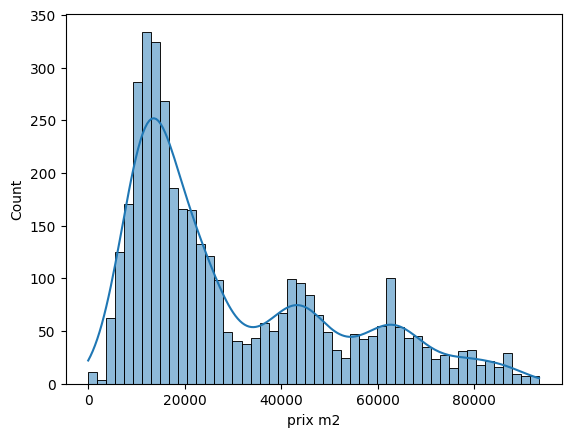

In [140]:
# distribution du prix m2 avec seaborn
import seaborn as sns
sns.histplot(df[cible], bins=50, kde=True)


In [141]:
Q1 = df['Surface (m2)'].quantile(0.25)
Q3 = df['Surface (m2)'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['Surface (m2)'] >= Q1 - 1.5 * IQR) & (df['Surface (m2)'] <= Q3 + 1.5 * IQR)]

<Axes: xlabel='Surface (m2)', ylabel='Count'>

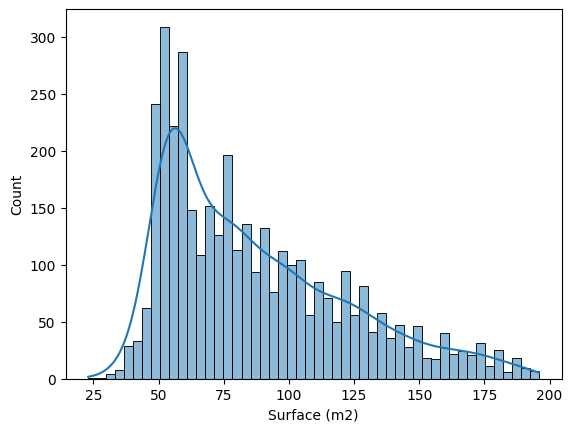

In [142]:
# distribution de surface avec seaborn
sns.histplot(df['Surface (m2)'], bins=50, kde=True)


In [143]:
mapping_etage = {
    'RDC': 0,
    'Etage 1': 1,
    'Etage 2': 2,
    'Etage 3': 3,
    'Etage 4': 4,
    'Etage 5': 5,
    'Etage 6': 6,
    'Etage 7': 7,
    'Etage 8': 8,
    'Etage 9': 9,
    'Etage 10': 10,
    'Etage 11': 11
}

# Appliquer le mapping
df['Etage'] = df['Etage'].map(mapping_etage)

df['Etage'] = df['Etage'].astype(int)

In [145]:
df['Chambres'] = df['Chambres'].fillna(2)


In [147]:
df_final = df.copy()
df_final.drop(columns=['Prix (DH)'], inplace=True)

In [148]:
df_final.to_excel("scrapping\\data\\avito_casablanca_apparts_prepared.xlsx", index=False)

In [149]:
vars_cat = df_final.select_dtypes(include='object').columns
vars_num = df_final.select_dtypes(include='number').columns

C:\Users\del\AppData\Local\Temp\ipykernel_12960\9218301.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  vars_cat = df_final.select_dtypes(include='object').columns


In [102]:
vars_cat

Index(['Secteur/Quartier', 'Type de bien', 'Etage', 'Condition', 'Standing'], dtype='str')

In [116]:
df_final['Chambres'] = df_final['Chambres'].fillna(2)

## Exploration des données (EDA)
Nous allons examiner la distribution des variables, les relations entre les variables numériques et la cible `prix m2`, et les caractéristiques principales des variables catégorielles.

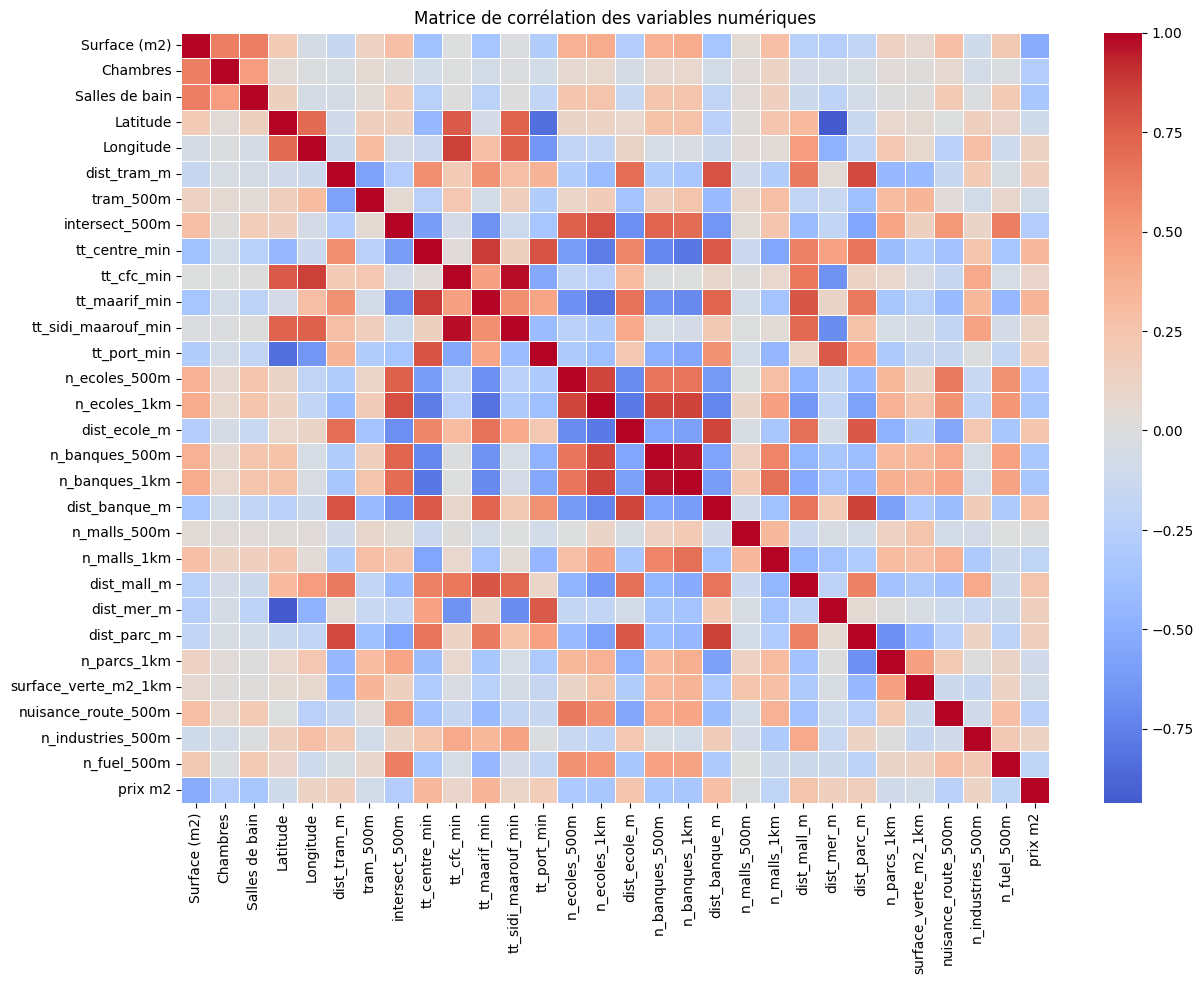

prix m2                 1.000000
tt_maarif_min           0.343185
tt_centre_min           0.324045
dist_banque_m           0.284284
dist_mall_m             0.248721
dist_ecole_m            0.241800
tt_port_min             0.181196
dist_parc_m             0.167603
dist_tram_m             0.156433
dist_mer_m              0.153661
Longitude               0.118148
n_industries_500m       0.115474
tt_sidi_maarouf_min     0.102390
tt_cfc_min              0.093360
n_malls_500m           -0.010977
surface_verte_m2_1km   -0.072532
tram_500m              -0.086364
n_parcs_1km            -0.096054
Latitude               -0.100951
n_fuel_500m            -0.196343
n_malls_1km            -0.201399
nuisance_route_500m    -0.227664
Chambres               -0.264777
intersect_500m         -0.268603
n_ecoles_500m          -0.308190
n_banques_500m         -0.323011
Salles de bain         -0.331376
n_banques_1km          -0.334527
n_ecoles_1km           -0.345224
Surface (m2)           -0.517833
Name: prix

In [108]:
import matplotlib.pyplot as plt
# Corrélation entre variables numériques et prix m2
corr = df_final[vars_num].corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0, fmt='.2f', linewidths=.5)
plt.title('Matrice de corrélation des variables numériques')
plt.show()

corr_target = corr[cible].sort_values(ascending=False)
corr_target

C:\Users\del\AppData\Local\Temp\ipykernel_12960\5606678.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')


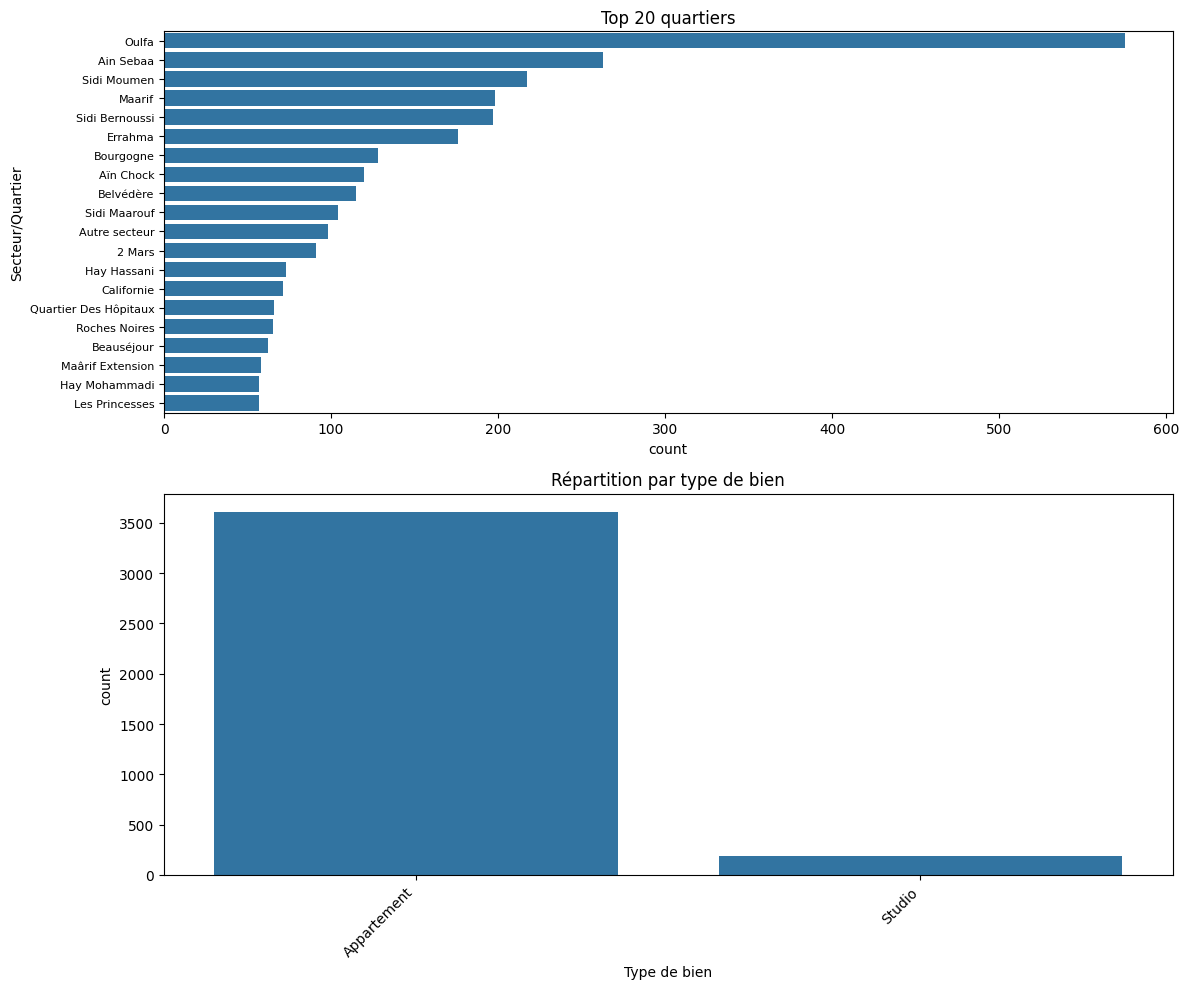

In [152]:
# Distribution des variables catégorielles principales
fig, axes = plt.subplots(2, 1, figsize=(12, 10))
sns.countplot(data=df_final, y='Secteur/Quartier', order=df_final['Secteur/Quartier'].value_counts().index[:20], ax=axes[0])
axes[0].set_title('Top 20 quartiers')
axes[0].tick_params(axis='y', labelsize=8)

sns.countplot(data=df_final, x='Type de bien', order=df_final['Type de bien'].value_counts().index, ax=axes[1])
axes[1].set_title('Répartition par type de bien')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

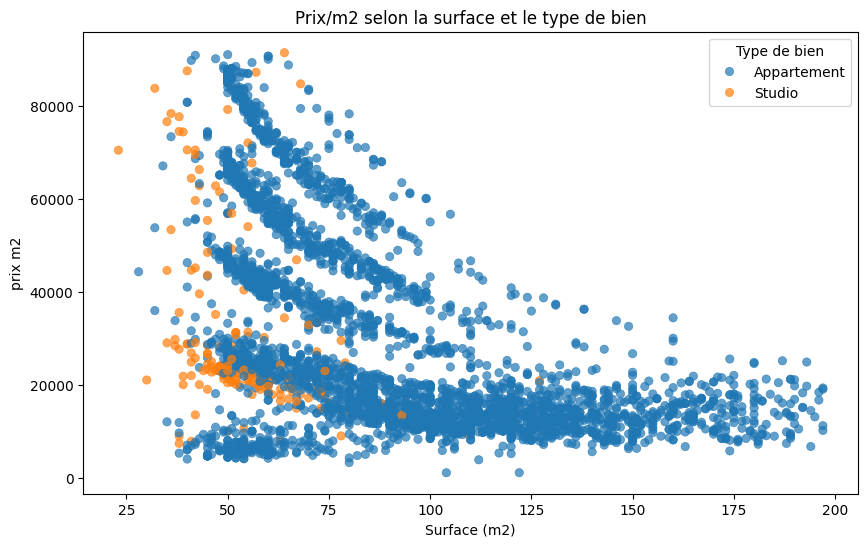

In [ ]:
# Relation entre surface et prix m2
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_final, x='Surface (m2)', y=cible, hue='Type de bien', alpha=0.7, edgecolor=None)
plt.title('Prix/m2 selon la surface et le type de bien')
plt.show()

In [ ]:
# On applique le LabelEncoder sur chaque colonne catégorielle
for col in vars_cat:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))


## Préparation des données et entraînement des modèles

Nous encodons les variables catégorielles, séparons train/test, puis entraînons une baseline et des modèles plus complexes avec CV.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder # Import de LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_percentage_error, make_scorer

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# 1. Préparation et copie des données
df_encoded = df_final.copy()

X = df_encoded.drop(columns=[cible])
y = df_encoded[cible]

vars_cat = X.select_dtypes(include='object').columns.tolist()
vars_num = X.select_dtypes(include='number').columns.tolist()

# 2. Application manuelle de LabelEncoder sur chaque colonne catégorielle
label_encoders = {}
for col in vars_cat:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le # On sauvegarde l'encodeur (très important pour l'API)

# 3. Configuration du préprocesseur (Uniquement pour le StandardScaler maintenant)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), vars_num)
    ],
    remainder='passthrough' # Crucial pour garder les colonnes encodées par LabelEncoder sans les modifier
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'Régression linéaire': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(random_state=42, n_jobs=-1, objective='reg:squarederror'),
    'LightGBM': LGBMRegressor(random_state=42, n_jobs=-1)
}

scoring = {
    'r2': 'r2',
    'neg_mape': make_scorer(mean_absolute_percentage_error, greater_is_better=False)
}

scores = []
for name, model in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)

    y_train_pred = pipe.predict(X_train)
    y_test_pred = pipe.predict(X_test)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    train_mape = mean_absolute_percentage_error(y_train, y_train_pred)
    test_mape = mean_absolute_percentage_error(y_test, y_test_pred)

    cv = cross_validate(pipe, X, y, cv=5, scoring=scoring, n_jobs=-1, return_train_score=False)
    cv_r2 = cv['test_r2'].mean()
    cv_r2_std = cv['test_r2'].std()
    cv_mape = -cv['test_neg_mape'].mean()
    cv_mape_std = -cv['test_neg_mape'].std()

    scores.append({
        'Modèle': name,
        'Train R2': train_r2,
        'Test R2': test_r2,
        'Train MAPE': train_mape,
        'Test MAPE': test_mape,
        'CV R2 (mean)': cv_r2,
        'CV R2 (std)': cv_r2_std,
        'CV MAPE (mean)': cv_mape,
        'CV MAPE (std)': cv_mape_std
    })

results = pd.DataFrame(scores)
results['R2 écart train-test'] = results['Train R2'] - results['Test R2']
results['MAPE écart train-test'] = results['Train MAPE'] - results['Test MAPE']
results

C:\Users\del\AppData\Local\Temp\ipykernel_12960\1210368688.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  vars_cat = X.select_dtypes(include='object').columns.tolist()


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001889 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1214
[LightGBM] [Info] Number of data points in the train set: 3035, number of used features: 34
[LightGBM] [Info] Start training from score 30680.966461


c:\Users\del\Desktop\prix-immobilier-evaluation\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\del\Desktop\prix-immobilier-evaluation\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,Modèle,Train R2,Test R2,Train MAPE,Test MAPE,CV R2 (mean),CV R2 (std),CV MAPE (mean),CV MAPE (std),R2 écart train-test,MAPE écart train-test
0,Régression linéaire,0.529825,0.506225,0.702191,0.734863,0.268195,0.417671,0.753402,-0.150563,0.023600,-0.032673
1,Decision Tree,0.995535,0.787117,0.008905,0.266429,0.618452,0.182189,0.315317,-0.046780,0.208419,-0.257525
2,Random Forest,0.976439,0.882905,0.088032,0.238493,0.784693,0.094908,0.264657,-0.034981,0.093534,-0.150461
3,XGBoost,0.983748,0.878312,0.080041,0.246265,0.767907,0.110940,0.276976,-0.040211,0.105437,-0.166223
4,LightGBM,0.940260,0.887837,0.155615,0.244911,0.797590,0.089959,0.254613,-0.042397,0.052423,-0.089295


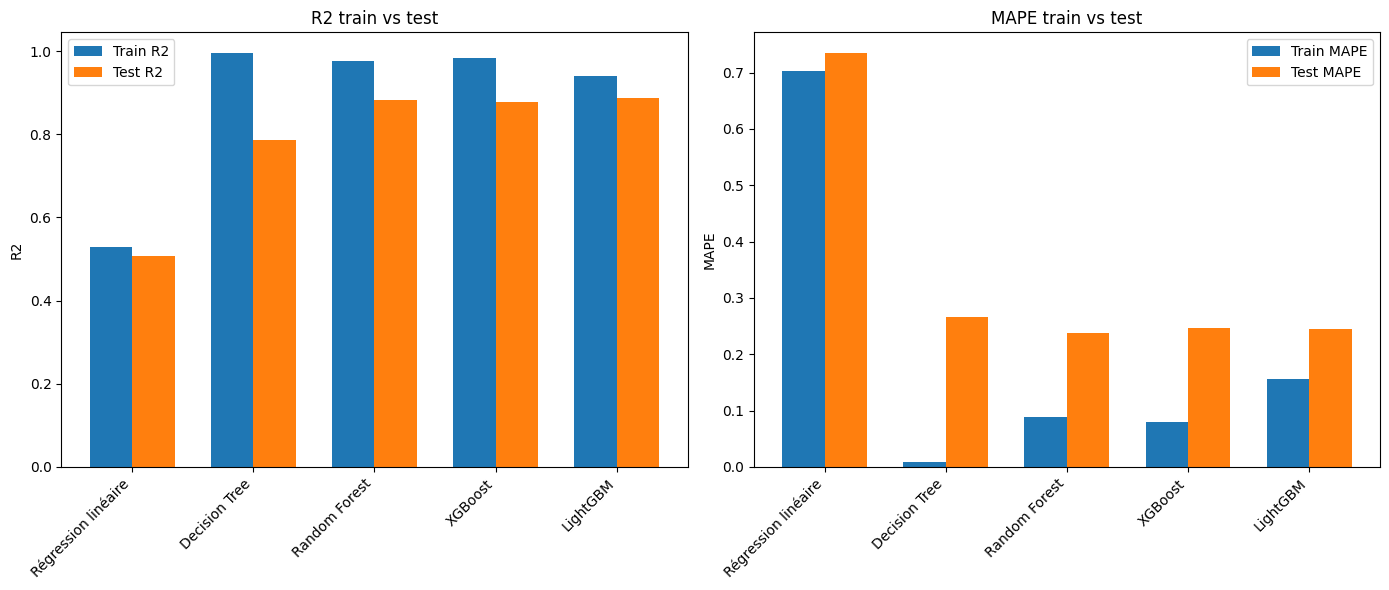

In [157]:
# Résumé des performances et vérification de l'overfitting
results_display = results[[
    'Modèle',
    'Train R2',
    'Test R2',
    'R2 écart train-test',
    'Train MAPE',
    'Test MAPE',
    'MAPE écart train-test',
    'CV R2 (mean)',
    'CV R2 (std)',
    'CV MAPE (mean)',
    'CV MAPE (std)'
]]
results_display

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
bar_width = 0.35
indices = range(len(results))
plt.bar([i - bar_width/2 for i in indices], results['Train R2'], width=bar_width, label='Train R2')
plt.bar([i + bar_width/2 for i in indices], results['Test R2'], width=bar_width, label='Test R2')
plt.xticks(indices, results['Modèle'], rotation=45, ha='right')
plt.ylabel('R2')
plt.title('R2 train vs test')
plt.legend()

plt.subplot(1, 2, 2)
plt.bar([i - bar_width/2 for i in indices], results['Train MAPE'], width=bar_width, label='Train MAPE')
plt.bar([i + bar_width/2 for i in indices], results['Test MAPE'], width=bar_width, label='Test MAPE')
plt.xticks(indices, results['Modèle'], rotation=45, ha='right')
plt.ylabel('MAPE')
plt.title('MAPE train vs test')
plt.legend()
plt.tight_layout()
plt.show()

## Recherche d'hyperparamètres pour XGBoost

In [158]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'model__n_estimators': [100, 200, 300, 400],
    'model__max_depth': [3, 5, 7, 9],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__subsample': [0.6, 0.8, 1.0],
    'model__colsample_bytree': [0.6, 0.8, 1.0],
    'model__reg_alpha': [0, 0.1, 0.5],
    'model__reg_lambda': [1, 2, 4]
}

pipe_xgb = Pipeline([('preprocessor', preprocessor), ('model', XGBRegressor(random_state=42, objective='reg:squarederror'))])

search = RandomizedSearchCV(
    estimator=pipe_xgb,
    param_distributions=param_dist,
    n_iter=30,
    scoring='r2',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

best_params = search.best_params_
best_score = search.best_score_

print('Meilleurs paramètres XGBoost :')
print(best_params)
print(f'Meilleur R2 CV (5 folds) : {best_score:.4f}')

y_test_pred = search.predict(X_test)
test_r2_xgb = r2_score(y_test, y_test_pred)
test_mape_xgb = mean_absolute_percentage_error(y_test, y_test_pred)

print(f'Test R2 XGBoost optimisé : {test_r2_xgb:.4f}')
print(f'Test MAPE XGBoost optimisé : {test_mape_xgb:.4f}')

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Meilleurs paramètres XGBoost :
{'model__subsample': 0.8, 'model__reg_lambda': 4, 'model__reg_alpha': 0, 'model__n_estimators': 200, 'model__max_depth': 5, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.8}
Meilleur R2 CV (5 folds) : 0.8586
Test R2 XGBoost optimisé : 0.8835
Test MAPE XGBoost optimisé : 0.2512


## Enregistrement du meilleur modèle XGBoost

On sauvegarde le pipeline complet du meilleur modèle XGBoost optimisé pour utilisation future.

In [159]:
import joblib
import os

# Chemin de sauvegarde
model_dir = 'model_artifacts'
os.makedirs(model_dir, exist_ok=True)

# Sauvegarder le pipeline complet (preprocessor + modèle)
model_path = os.path.join(model_dir, 'best_xgboost_pipeline.joblib')
joblib.dump(search.best_estimator_, model_path)

print(f'Modèle XGBoost optimisé enregistré : {model_path}')

# Sauvegarder les meilleurs paramètres
params_path = os.path.join(model_dir, 'best_hyperparams_xgboost.joblib')
joblib.dump(best_params, params_path)

print(f'Meilleurs paramètres enregistrés : {params_path}')

# Sauvegarder les feature names pour utilisation future
feature_names_path = os.path.join(model_dir, 'feature_names.joblib')
joblib.dump(feature_names, feature_names_path)

print(f'Noms des features enregistrés : {feature_names_path}')

# Résumé
print('\n--- Résumé du modèle sauvegardé ---')
print(f'Meilleur R2 CV : {best_score:.4f}')
print(f'Test R2 : {test_r2_xgb:.4f}')
print(f'Test MAPE : {test_mape_xgb:.4f}')

Modèle XGBoost optimisé enregistré : model_artifacts\best_xgboost_pipeline.joblib
Meilleurs paramètres enregistrés : model_artifacts\best_hyperparams_xgboost.joblib
Noms des features enregistrés : model_artifacts\feature_names.joblib

--- Résumé du modèle sauvegardé ---
Meilleur R2 CV : 0.8586
Test R2 : 0.8835
Test MAPE : 0.2512


In [163]:
import shap
import textwrap, inspect
import warnings
warnings.filterwarnings('ignore')

# ── Patch de compatibilité XGBoost ≥ 3.x / SHAP 0.49 ─────────────────────
# XGBoost 3 stocke base_score sous la forme '[3.0680967E4]' (notation tableau)
# alors que SHAP attend un float. Ce patch corrige le parsing au vol.
import shap.explainers._tree as _shap_tree

_orig_src  = textwrap.dedent(inspect.getsource(_shap_tree.XGBTreeModelLoader.__init__))
_patched   = _orig_src.replace(
    'float(learner_model_param["base_score"])',
    'float(str(learner_model_param["base_score"]).strip("[]"))'
)
exec(_patched, _shap_tree.XGBTreeModelLoader.__init__.__globals__)
_shap_tree.XGBTreeModelLoader.__init__ = \
    _shap_tree.XGBTreeModelLoader.__init__.__globals__['__init__']

print('SHAP version :', shap.__version__)
print('Patch XGBoost 3.x appliqué ✓')

SHAP version : 0.51.0
Patch XGBoost 3.x appliqué ✓


In [164]:
import numpy as np

# Récupérer le meilleur pipeline
best_pipeline   = search.best_estimator_
best_pre        = best_pipeline.named_steps['preprocessor']
best_xgb        = best_pipeline.named_steps['model']

# Background SHAP : échantillon de X_test (100 obs max pour la rapidité)
rng             = np.random.RandomState(42)
n_bg            = min(100, len(X_test))
idx_bg          = rng.choice(len(X_test), n_bg, replace=False)
X_bg_raw        = X_test.iloc[idx_bg]
X_bg_transformed = best_pre.transform(X_bg_raw)

# Noms des features après preprocessing
feat_names = [
    f.replace('num__', '').replace('remainder__', '')
    for f in best_pre.get_feature_names_out()
]

# Calcul des valeurs SHAP sur tout X_test
explainer  = shap.TreeExplainer(best_xgb, X_bg_transformed)
X_test_transformed = best_pre.transform(X_test)
shap_values = explainer(X_test_transformed)
shap_values.feature_names = feat_names

print(f'SHAP calculé sur {len(X_test)} observations de test')
print(f'Valeur de base (prédiction moyenne) : {explainer.expected_value:,.0f} DH/m²')

SHAP calculé sur 759 observations de test
Valeur de base (prédiction moyenne) : 33,702 DH/m²


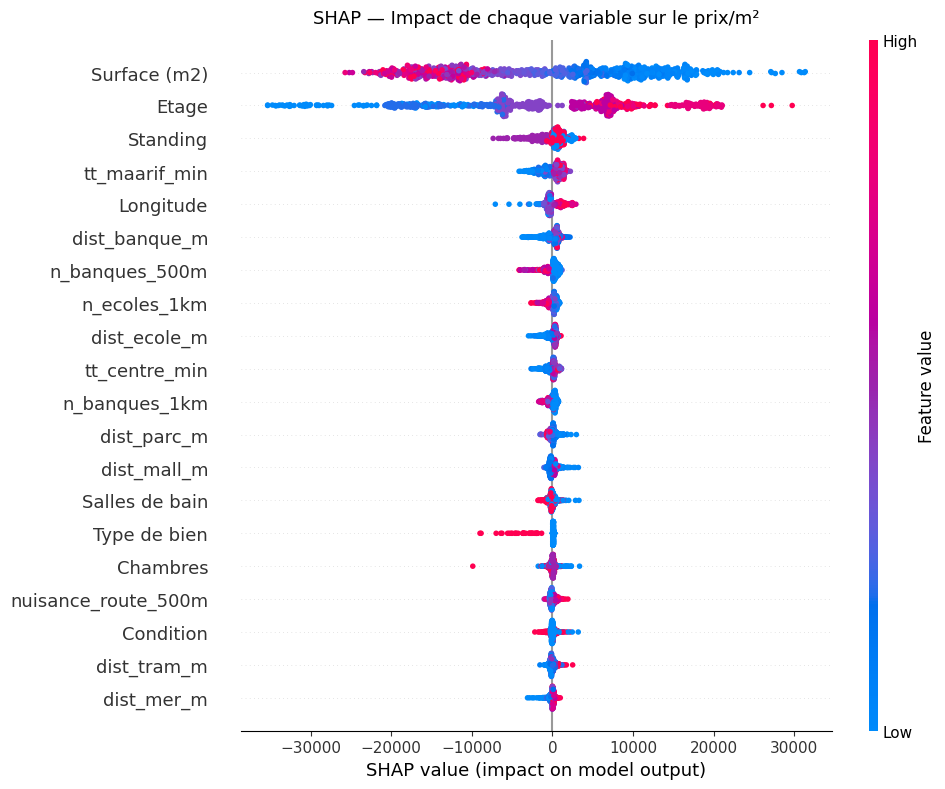

In [165]:
# ── Summary plot (beeswarm) ───────────────────────────────────────────────
# Chaque point représente une observation.
# Axe X  = valeur SHAP (impact sur la prédiction)
# Couleur = valeur de la variable (rouge = élevée, bleu = faible)

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values.values,
    X_test_transformed,
    feature_names = feat_names,
    show          = False,
    plot_size     = (10, 8),
)
plt.title('SHAP — Impact de chaque variable sur le prix/m²', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

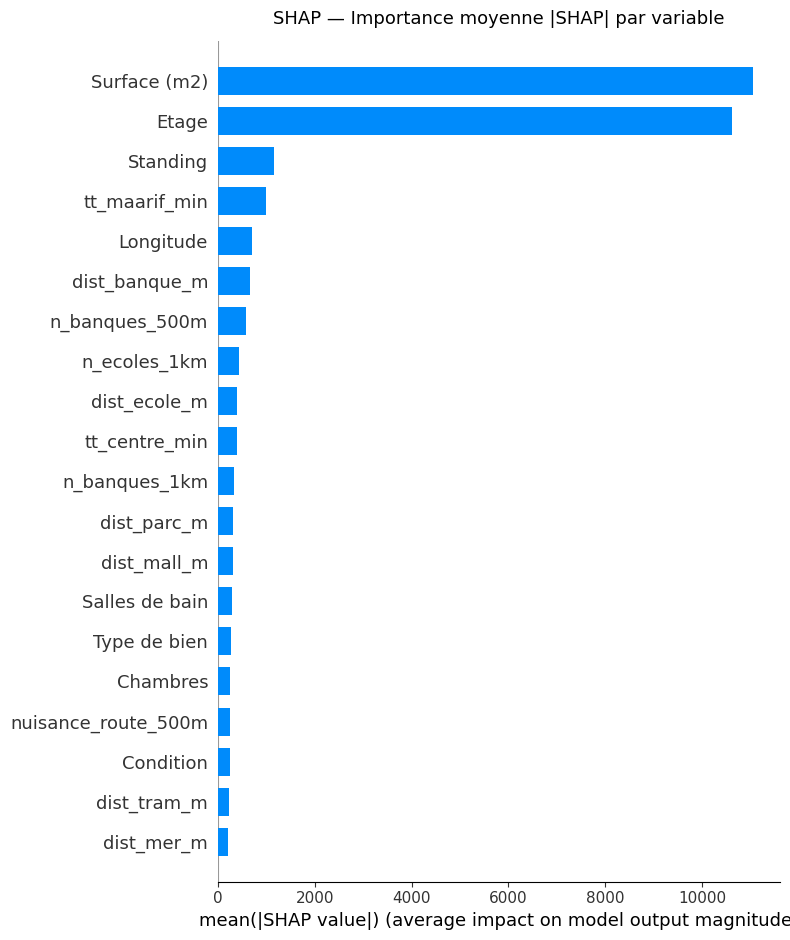


Top 10 variables par importance SHAP moyenne :


,Feature,Mean |SHAP|
1,Surface (m2),11056.509959
2,Etage,10611.838181
3,Standing,1165.917692
4,tt_maarif_min,984.758580
5,Longitude,705.832946
6,dist_banque_m,664.818985
7,n_banques_500m,576.092685
8,n_ecoles_1km,436.370280
9,dist_ecole_m,401.048331
10,tt_centre_min,398.429786


In [166]:
# ── Bar plot — importance absolue moyenne ─────────────────────────────────
# Montre les variables les plus influentes en moyenne sur l'ensemble du dataset.

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values.values,
    X_test_transformed,
    feature_names = feat_names,
    plot_type     = 'bar',
    show          = False,
)
plt.title('SHAP — Importance moyenne |SHAP| par variable', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

# Tableau top-10
mean_abs = np.abs(shap_values.values).mean(axis=0)
top10 = (
    pd.DataFrame({'Feature': feat_names, 'Mean |SHAP|': mean_abs})
    .sort_values('Mean |SHAP|', ascending=False)
    .head(10)
    .reset_index(drop=True)
)
top10.index += 1
print('\nTop 10 variables par importance SHAP moyenne :')
top10

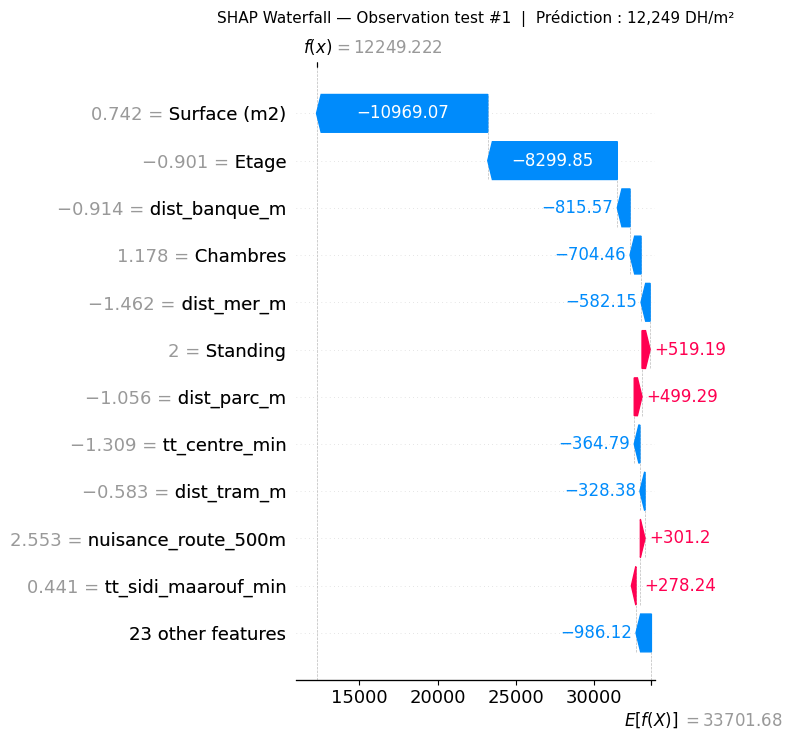

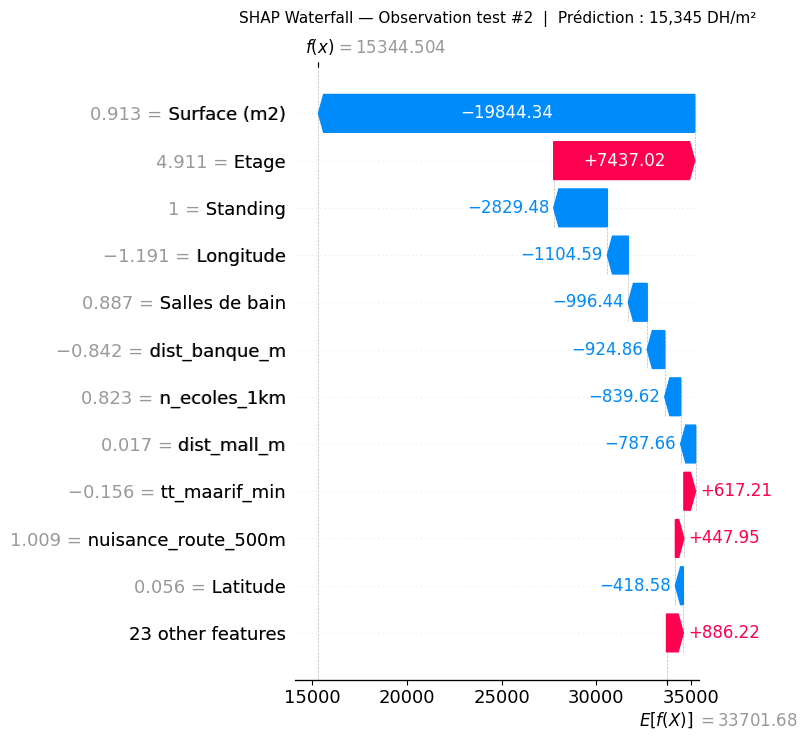

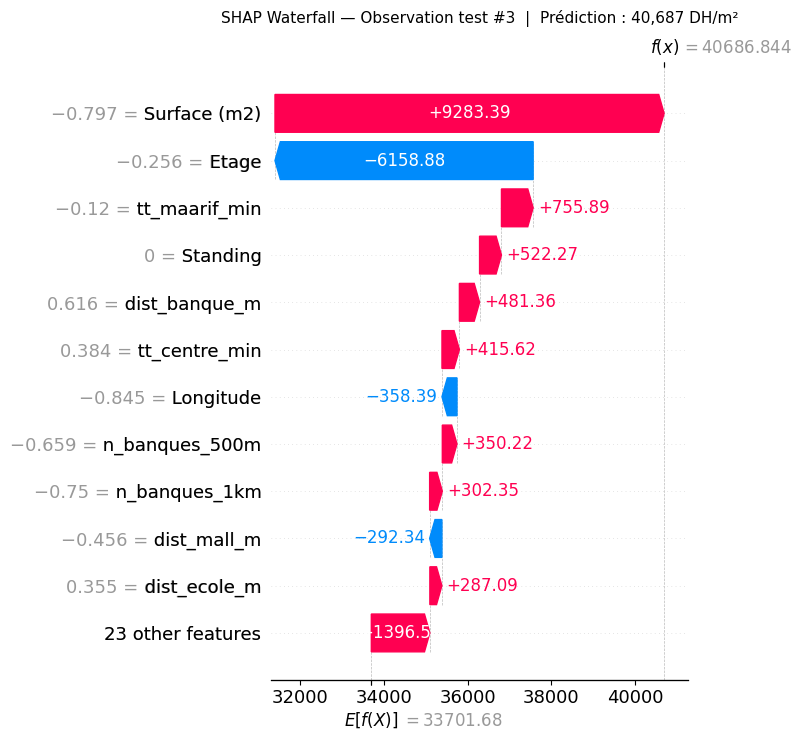

In [167]:
# ── Waterfall plots — explication de 3 prédictions individuelles ──────────
# Le waterfall plot décompose la prédiction d'un appartement précis :
#   - point de départ = valeur de base (prédiction moyenne)
#   - chaque barre = contribution SHAP d'une variable
#   - point d'arrivée = prédiction finale

for i, titre in enumerate(['Observation test #1', 'Observation test #2', 'Observation test #3']):
    fig, ax = plt.subplots(figsize=(10, 6))
    shap.waterfall_plot(shap_values[i], max_display=12, show=False)
    plt.title(f'SHAP Waterfall — {titre}  |  Prédiction : {best_pipeline.predict(X_test.iloc[[i]])[0]:,.0f} DH/m²',
              fontsize=11, pad=10)
    plt.tight_layout()
    plt.show()